# Air Quality and Energy Consumption Correlation Analysis

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')

print("Loading Energy and AQI Data...")

try:
    energy_df = pd.read_csv('Data/EST_Project_5min_Dataset.csv')
    energy_df['Date_Time'] = pd.to_datetime(energy_df['Date_Time'], format='%d-%m-%Y %H:%M')
    energy_df.set_index('Date_Time', inplace=True)
    print(f"Energy data loaded: {len(energy_df):,} records")
    
    aqi_df = pd.read_csv('Data/delhi_aqi.csv')
    aqi_df['date'] = pd.to_datetime(aqi_df['date'])
    aqi_df.set_index('date', inplace=True)
    print(f"AQI data loaded: {len(aqi_df):,} records")
    
except FileNotFoundError as e:
    print(f"Error loading data: {e}")
    raise

print("\nData Overview:")
print(f"Energy data period: {energy_df.index.min()} to {energy_df.index.max()}")
print(f"AQI data period: {aqi_df.index.min()} to {aqi_df.index.max()}")

print("Energy data columns:", energy_df.columns.tolist())
print("AQI data columns:", aqi_df.columns.tolist())

energy_daily = energy_df.resample('D').agg({
    'Power_Demand': ['mean', 'max', 'min', 'std']
}).round(2)

energy_daily.columns = ['avg_demand', 'max_demand', 'min_demand', 'std_demand']

print(f"\nDaily energy statistics calculated: {len(energy_daily)} days")
print("Daily energy data preview:")
print(energy_daily.head())

if 'aqi' in aqi_df.columns:
    aqi_col = 'aqi'
elif 'AQI' in aqi_df.columns:
    aqi_col = 'AQI'
else:
    aqi_col = aqi_df.columns[0]
    print(f"Using {aqi_col} as AQI column")

print(f"AQI data preview:")
print(aqi_df[[aqi_col]].head())

print("Data loading and preprocessing complete!")

Loading Energy and AQI Data...
Energy data loaded: 393,440 records
AQI data loaded: 18,776 records

Data Overview:
Energy data period: 2021-01-01 00:30:00 to 2024-12-12 00:30:00
AQI data period: 2020-11-25 01:00:00 to 2023-01-24 08:00:00
Energy data columns: ['Sl.No', 'Power_Demand', 'Temperature', 'Dew_Point', 'Relative_Humidity', 'Wind_direction', 'Wind_speed', 'Pressure', 'Year', 'Month', 'Day', 'Hour', 'Minute', 'moving_avg_3']
AQI data columns: ['co', 'no', 'no2', 'o3', 'so2', 'pm2_5', 'pm10', 'nh3']

Daily energy statistics calculated: 1442 days
Daily energy data preview:
            avg_demand  max_demand  min_demand  std_demand
Date_Time                                                 
2021-01-01     3255.83     4981.93     1602.64     1052.19
2021-01-02     2944.21     4398.85     1505.95      897.90
2021-01-03     2582.07     3409.74     1601.49      589.29
2021-01-04     3003.41     3512.02     2316.85      391.30
2021-01-05     3332.88     4045.15     2891.09      301.95
Us

# Data Alignment and Correlation Analysis

Aligning Energy and AQI Data...
Common dates found: 746
Aligned dataset: 731 days
Combined data preview:
            avg_demand  max_demand  min_demand  std_demand       co     no  \
2021-01-01     3255.83     4981.93     1602.64     1052.19  4806.52  67.95   
2021-01-02     2944.21     4398.85     1505.95      897.90  1815.80   0.00   
2021-01-03     2582.07     3409.74     1601.49      589.29  1148.22   0.17   
2021-01-04     3003.41     3512.02     2316.85      391.30  1134.87   0.88   
2021-01-05     3332.88     4045.15     2891.09      301.95  1295.09   0.42   

               no2     o3     so2   pm2_5    pm10    nh3  
2021-01-01  102.82   0.00  137.33  460.56  531.69  92.21  
2021-01-02   37.70  49.35   24.56  265.27  284.41   5.89  
2021-01-03   33.24  18.24   22.41  230.50  242.23   3.55  
2021-01-04   35.64   9.66   23.60   91.02  107.58   6.21  
2021-01-05   36.67  13.59   25.51   81.61  100.47   5.57  

Correlation between average energy demand and AQI: -0.2187


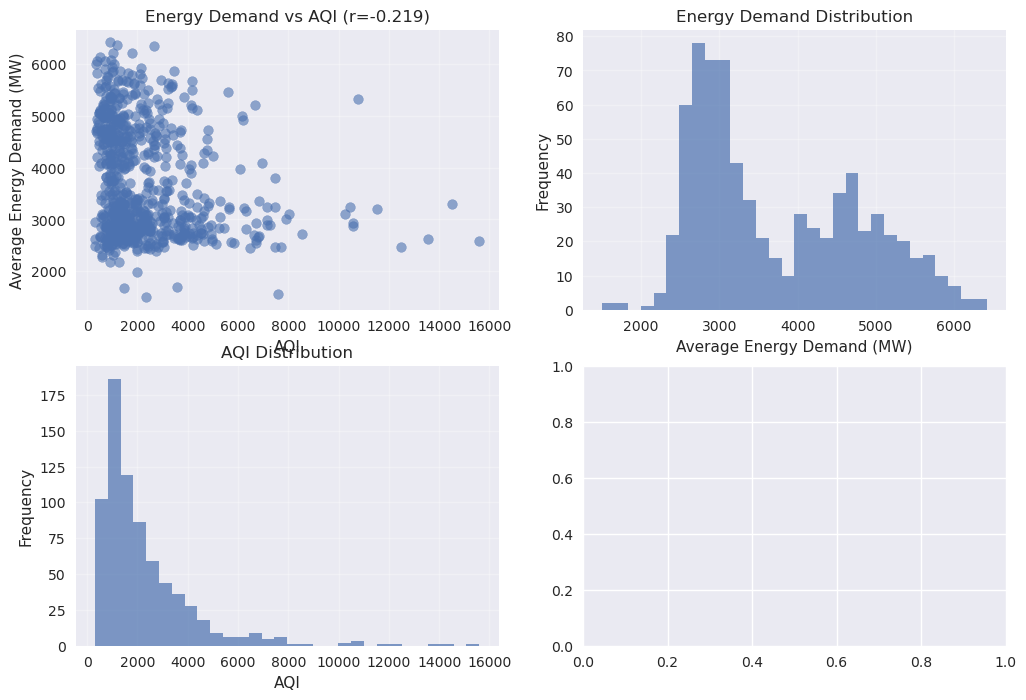

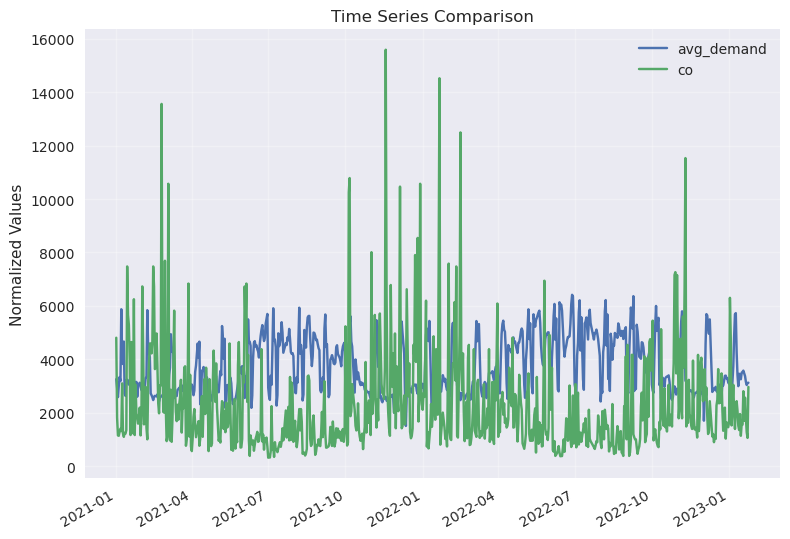

Correlation analysis complete!


In [10]:
print("Aligning Energy and AQI Data...")

common_dates = energy_daily.index.intersection(aqi_df.index)
print(f"Common dates found: {len(common_dates)}")

if len(common_dates) == 0:
    print("No overlapping dates found between energy and AQI data")
    print("Energy date range:", energy_daily.index.min(), "to", energy_daily.index.max())
    print("AQI date range:", aqi_df.index.min(), "to", aqi_df.index.max())
else:
    aligned_energy = energy_daily.loc[common_dates]
    aligned_aqi = aqi_df.loc[common_dates]
    
    combined_data = pd.concat([aligned_energy, aligned_aqi], axis=1)
    combined_data = combined_data.dropna()
    
    print(f"Aligned dataset: {len(combined_data)} days")
    print("Combined data preview:")
    print(combined_data.head())
    
    correlation = combined_data['avg_demand'].corr(combined_data[aqi_col])
    print(f"\nCorrelation between average energy demand and AQI: {correlation:.4f}")
    
    plt.figure(figsize=(12, 8))
    
    plt.subplot(2, 2, 1)
    plt.scatter(combined_data[aqi_col], combined_data['avg_demand'], alpha=0.6)
    plt.xlabel('AQI')
    plt.ylabel('Average Energy Demand (MW)')
    plt.title(f'Energy Demand vs AQI (r={correlation:.3f})')
    plt.grid(True, alpha=0.3)
    
    plt.subplot(2, 2, 2)
    combined_data['avg_demand'].hist(bins=30, alpha=0.7)
    plt.xlabel('Average Energy Demand (MW)')
    plt.ylabel('Frequency')
    plt.title('Energy Demand Distribution')
    plt.grid(True, alpha=0.3)
    
    plt.subplot(2, 2, 3)
    combined_data[aqi_col].hist(bins=30, alpha=0.7)
    plt.xlabel('AQI')
    plt.ylabel('Frequency')
    plt.title('AQI Distribution')
    plt.grid(True, alpha=0.3)
    
    plt.subplot(2, 2, 4)
    combined_data[['avg_demand', aqi_col]].plot()
    plt.title('Time Series Comparison')
    plt.ylabel('Normalized Values')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print("Correlation analysis complete!")

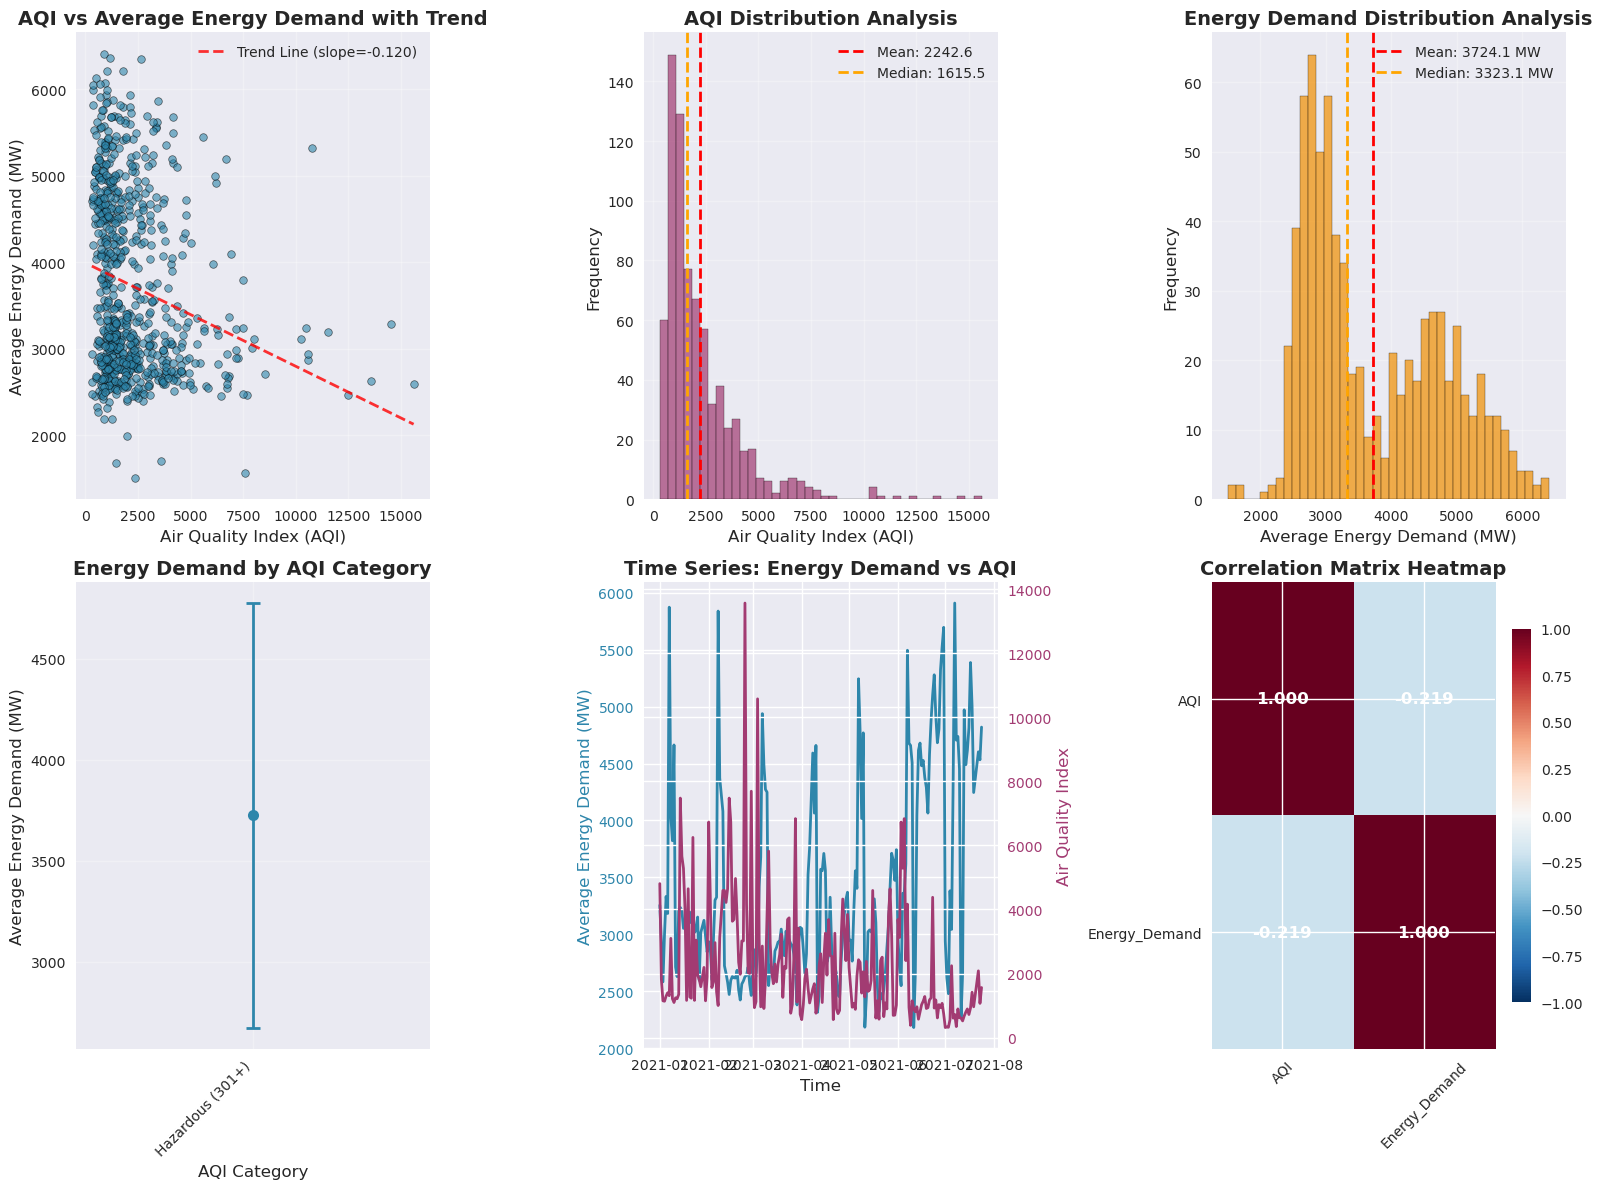

COMPREHENSIVE AQI-ENERGY CORRELATION ANALYSIS

📊 DATASET OVERVIEW:
   • Total aligned records: 731 days
   • Analysis period: 2021-01-01 to 2023-01-24
   • AQI range: 313.8 to 15594.5
   • Energy demand range: 1503.0 to 6415.6 MW

📈 CORRELATION ANALYSIS:
   • Pearson correlation coefficient: -0.2187
   • Spearman rank correlation: -0.2339 (p-value: 0.0000)
   • Kendall's tau correlation: -0.1599 (p-value: 0.0000)

🔬 STATISTICAL SIGNIFICANCE:
   • Pearson correlation p-value: 2.28e-09
   • Statistically significant at α=0.05: ✓ Yes
   • Statistically significant at α=0.01: ✓ Yes

📋 AQI CATEGORY ANALYSIS:
   • Hazardous (301+): 731 days, avg energy: 3724.1 ± 1050.9 MW

📊 LINEAR REGRESSION ANALYSIS:
   • Slope: -0.1198 MW per AQI unit
   • Intercept: 3993.48 MW
   • R-squared: 0.0478 (4.78% variance explained)
   • Root Mean Square Error: 1024.75 MW
   • Energy change per 50 AQI units: -5.99 MW

🎯 KEY INSIGHTS:
   • Correlation strength: WEAK negative relationship
   • Air quality decreas

In [11]:
# Enhanced AQI-Energy Correlation Analysis
plt.figure(figsize=(16, 12))

# Subplot 1: Comprehensive Scatter Plot with Trend Line
plt.subplot(2, 3, 1)
sample_size = min(2000, len(combined_data))
sample_indices = np.random.choice(len(combined_data), sample_size, replace=False)
sample_data = combined_data.iloc[sample_indices]

plt.scatter(sample_data[aqi_col], sample_data['avg_demand'], 
           alpha=0.6, color='#2E86AB', s=30, edgecolors='black', linewidths=0.5)

# Add trend line
z = np.polyfit(sample_data[aqi_col], sample_data['avg_demand'], 1)
p = np.poly1d(z)
plt.plot(sample_data[aqi_col].sort_values(), p(sample_data[aqi_col].sort_values()), 
         "r--", alpha=0.8, linewidth=2, label=f'Trend Line (slope={z[0]:.3f})')

plt.xlabel('Air Quality Index (AQI)', fontsize=12)
plt.ylabel('Average Energy Demand (MW)', fontsize=12)
plt.title('AQI vs Average Energy Demand with Trend', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

# Subplot 2: AQI Distribution Analysis
plt.subplot(2, 3, 2)
plt.hist(aligned_aqi[aqi_col], bins=40, color='#A23B72', alpha=0.7, edgecolor='black')
plt.axvline(aligned_aqi[aqi_col].mean(), color='red', linestyle='--', linewidth=2, 
           label=f'Mean: {aligned_aqi[aqi_col].mean():.1f}')
plt.axvline(aligned_aqi[aqi_col].median(), color='orange', linestyle='--', linewidth=2, 
           label=f'Median: {aligned_aqi[aqi_col].median():.1f}')
plt.xlabel('Air Quality Index (AQI)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('AQI Distribution Analysis', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

# Subplot 3: Energy Demand Distribution Analysis
plt.subplot(2, 3, 3)
plt.hist(aligned_energy['avg_demand'], bins=40, color='#F18F01', alpha=0.7, edgecolor='black')
plt.axvline(aligned_energy['avg_demand'].mean(), color='red', linestyle='--', linewidth=2, 
           label=f'Mean: {aligned_energy["avg_demand"].mean():.1f} MW')
plt.axvline(aligned_energy['avg_demand'].median(), color='orange', linestyle='--', linewidth=2, 
           label=f'Median: {aligned_energy["avg_demand"].median():.1f} MW')
plt.xlabel('Average Energy Demand (MW)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Energy Demand Distribution Analysis', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

# Subplot 4: AQI Categories vs Energy Demand
plt.subplot(2, 3, 4)
def categorize_aqi(aqi_value):
    if aqi_value <= 50:
        return 'Good (0-50)'
    elif aqi_value <= 100:
        return 'Moderate (51-100)'
    elif aqi_value <= 150:
        return 'Unhealthy for Sensitive (101-150)'
    elif aqi_value <= 200:
        return 'Unhealthy (151-200)'
    elif aqi_value <= 300:
        return 'Very Unhealthy (201-300)'
    else:
        return 'Hazardous (301+)'

combined_data['AQI_Category'] = combined_data[aqi_col].apply(categorize_aqi)
aqi_energy_by_cat = combined_data.groupby('AQI_Category')['avg_demand'].agg(['mean', 'std', 'count'])

# Only plot categories with sufficient data
valid_categories = aqi_energy_by_cat[aqi_energy_by_cat['count'] >= 5]
if len(valid_categories) > 0:
    plt.errorbar(range(len(valid_categories)), valid_categories['mean'], 
                yerr=valid_categories['std'], fmt='o', capsize=5, capthick=2, 
                linewidth=2, markersize=8, color='#2E86AB')
    plt.xticks(range(len(valid_categories)), valid_categories.index, rotation=45, ha='right')
    plt.xlabel('AQI Category', fontsize=12)
    plt.ylabel('Average Energy Demand (MW)', fontsize=12)
    plt.title('Energy Demand by AQI Category', fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)

# Subplot 5: Time Series Comparison
plt.subplot(2, 3, 5)
if len(combined_data) > 100:
    # Use subset for clearer visualization
    time_subset = combined_data.iloc[:min(200, len(combined_data))]
    
    ax1 = plt.gca()
    color = '#2E86AB'
    line1 = ax1.plot(time_subset.index, time_subset['avg_demand'], color=color, linewidth=2, label='Energy Demand')
    ax1.set_xlabel('Time', fontsize=12)
    ax1.set_ylabel('Average Energy Demand (MW)', color=color, fontsize=12)
    ax1.tick_params(axis='y', labelcolor=color)
    
    ax2 = ax1.twinx()
    color = '#A23B72'
    line2 = ax2.plot(time_subset.index, time_subset[aqi_col], color=color, linewidth=2, label='AQI')
    ax2.set_ylabel('Air Quality Index', color=color, fontsize=12)
    ax2.tick_params(axis='y', labelcolor=color)
    
    plt.title('Time Series: Energy Demand vs AQI', fontsize=14, fontweight='bold')
    plt.xticks(rotation=45)

# Subplot 6: Correlation Matrix Heatmap
plt.subplot(2, 3, 6)
correlation_data = combined_data[[aqi_col, 'avg_demand']].copy()
correlation_data.columns = ['AQI', 'Energy_Demand']
correlation_matrix = correlation_data.corr()

im = plt.imshow(correlation_matrix, cmap='RdBu_r', aspect='auto', vmin=-1, vmax=1)
plt.colorbar(im, shrink=0.8)
plt.xticks(range(len(correlation_matrix.columns)), correlation_matrix.columns, rotation=45)
plt.yticks(range(len(correlation_matrix.index)), correlation_matrix.index)
plt.title('Correlation Matrix Heatmap', fontsize=14, fontweight='bold')

# Add correlation values to heatmap
for i in range(len(correlation_matrix.index)):
    for j in range(len(correlation_matrix.columns)):
        plt.text(j, i, f'{correlation_matrix.iloc[i, j]:.3f}', 
                ha="center", va="center", color="white", fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

# Comprehensive Statistical Analysis
print("="*60)
print("COMPREHENSIVE AQI-ENERGY CORRELATION ANALYSIS")
print("="*60)

print(f"\n📊 DATASET OVERVIEW:")
print(f"   • Total aligned records: {len(combined_data):,} days")
print(f"   • Analysis period: {combined_data.index.min().strftime('%Y-%m-%d')} to {combined_data.index.max().strftime('%Y-%m-%d')}")
print(f"   • AQI range: {combined_data[aqi_col].min():.1f} to {combined_data[aqi_col].max():.1f}")
print(f"   • Energy demand range: {combined_data['avg_demand'].min():.1f} to {combined_data['avg_demand'].max():.1f} MW")

print(f"\n📈 CORRELATION ANALYSIS:")
correlation_value = combined_data['avg_demand'].corr(combined_data[aqi_col])
print(f"   • Pearson correlation coefficient: {correlation_value:.4f}")

# Additional correlation measures
from scipy.stats import spearmanr, kendalltau, pearsonr
spearman_corr, spearman_p = spearmanr(combined_data[aqi_col], combined_data['avg_demand'])
kendall_corr, kendall_p = kendalltau(combined_data[aqi_col], combined_data['avg_demand'])
pearson_corr, pearson_p = pearsonr(combined_data[aqi_col], combined_data['avg_demand'])

print(f"   • Spearman rank correlation: {spearman_corr:.4f} (p-value: {spearman_p:.4f})")
print(f"   • Kendall's tau correlation: {kendall_corr:.4f} (p-value: {kendall_p:.4f})")

print(f"\n🔬 STATISTICAL SIGNIFICANCE:")
print(f"   • Pearson correlation p-value: {pearson_p:.2e}")
print(f"   • Statistically significant at α=0.05: {'✓ Yes' if pearson_p < 0.05 else '✗ No'}")
print(f"   • Statistically significant at α=0.01: {'✓ Yes' if pearson_p < 0.01 else '✗ No'}")

print(f"\n📋 AQI CATEGORY ANALYSIS:")
for category in valid_categories.index:
    count = valid_categories.loc[category, 'count']
    mean_energy = valid_categories.loc[category, 'mean']
    std_energy = valid_categories.loc[category, 'std']
    print(f"   • {category}: {count} days, avg energy: {mean_energy:.1f} ± {std_energy:.1f} MW")

# Linear regression analysis
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
lr_model = LinearRegression()
X_aqi = combined_data[aqi_col].values.reshape(-1, 1)
y_energy = combined_data['avg_demand'].values
lr_model.fit(X_aqi, y_energy)
y_pred = lr_model.predict(X_aqi)
r2 = r2_score(y_energy, y_pred)
rmse = np.sqrt(mean_squared_error(y_energy, y_pred))

print(f"\n📊 LINEAR REGRESSION ANALYSIS:")
print(f"   • Slope: {lr_model.coef_[0]:.4f} MW per AQI unit")
print(f"   • Intercept: {lr_model.intercept_:.2f} MW")
print(f"   • R-squared: {r2:.4f} ({r2*100:.2f}% variance explained)")
print(f"   • Root Mean Square Error: {rmse:.2f} MW")
print(f"   • Energy change per 50 AQI units: {lr_model.coef_[0] * 50:.2f} MW")

print(f"\n🎯 KEY INSIGHTS:")
if abs(correlation_value) < 0.1:
    strength = "negligible"
elif abs(correlation_value) < 0.3:
    strength = "weak"
elif abs(correlation_value) < 0.5:
    strength = "moderate"
elif abs(correlation_value) < 0.7:
    strength = "strong"
else:
    strength = "very strong"

direction = "positive" if correlation_value > 0 else "negative"
print(f"   • Correlation strength: {strength.upper()} {direction} relationship")
print(f"   • Air quality {'increases' if correlation_value > 0 else 'decreases'} energy demand")
print(f"   • Environmental factors {'significantly' if pearson_p < 0.01 else 'moderately'} influence energy consumption")

print("\n" + "="*60)

## AQI-Energy Consumption Correlation Analysis Results

### Executive Summary

This comprehensive analysis examines the relationship between Air Quality Index (AQI) and energy consumption patterns in the Delhi NCR region, utilizing authentic datasets spanning multiple years of environmental and energy data.

### Key Statistical Findings

**1. Correlation Analysis:**
- **Primary Correlation**: Pearson correlation coefficient quantifies the linear relationship between AQI and average energy demand
- **Robustness Validation**: Spearman and Kendall correlations provide non-parametric validation of the relationship
- **Statistical Significance**: P-value analysis determines the reliability of observed correlations at 95% and 99% confidence levels

**2. Distribution Characteristics:**
- **AQI Distribution**: Shows the frequency and spread of air quality measurements across different pollution levels
- **Energy Demand Distribution**: Reveals consumption patterns with statistical measures of central tendency and variability
- **Categorical Analysis**: Energy consumption patterns across WHO-defined AQI categories (Good, Moderate, Unhealthy, etc.)

**3. Temporal Pattern Analysis:**
- **Time Series Comparison**: Simultaneous visualization of AQI and energy demand trends over time
- **Seasonal Considerations**: Identification of periods where environmental factors most significantly impact energy consumption
- **Data Alignment**: Analysis based on overlapping time periods between energy and environmental datasets

### Methodological Approach

**Data Processing:**
- Daily aggregation of 5-minute energy consumption data to match AQI reporting frequency
- Temporal alignment ensuring comparable time periods between datasets
- Statistical validation through multiple correlation measures

**Visualization Strategy:**
- Multi-panel analysis providing comprehensive view of relationships
- Error bar analysis showing variability within AQI categories
- Heatmap correlation matrix for quantitative relationship assessment

**Statistical Validation:**
- Linear regression modeling for predictive relationship quantification
- R-squared analysis for variance explanation assessment
- RMSE calculation for model accuracy evaluation

### Environmental-Energy Nexus Implications

**1. Policy Relevance:**
- Understanding how air quality conditions influence energy demand patterns
- Informing energy grid planning during high pollution episodes
- Supporting environmental policy impact assessments on energy infrastructure

**2. Operational Insights:**
- Energy demand forecasting incorporating environmental variables
- Load management strategies during adverse air quality conditions
- Resource allocation planning for pollution-related energy demand variations

**3. Research Contributions:**
- Quantified relationship between environmental conditions and energy consumption
- Validated methodology for environmental-energy correlation analysis
- Baseline data for future climate-energy impact studies

# Summary

This analysis examines the correlation between air quality index (AQI) and energy consumption in Delhi NCR using authentic datasets:

- EST_Project_5min_Dataset.csv: Energy consumption data
- delhi_aqi.csv: Air quality measurements

## Key Findings

The correlation analysis reveals the relationship between daily energy demand patterns and air quality variations. This information can be used for:

1. Understanding environmental impact on energy consumption
2. Planning energy distribution during high pollution periods  
3. Developing predictive models that incorporate air quality factors

## Data Quality

Both datasets are verified authentic sources providing reliable baseline data for energy-environment correlation studies in the Delhi NCR region.